In [1]:
%autosave 60
%pip install --quiet -r requirements.txt

Autosaving every 60 seconds
Note: you may need to restart the kernel to use updated packages.


# EX2 — Feature Selection for FiLM Conditioning

Two-phase pipeline:
1. **Gradient importance** — rank all 36 features using the champion FiLM model (no retraining).
2. **Sequential Forward Selection (SFS)** — greedily select the best subset from the top-K candidates.

## 1. Imports & Setup

In [2]:
import yaml
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils.data_loader import DataLoader
from utils.health_data_loader import HealthDataLoader
from utils.combined_metadata_loader import CombinedMetadataLoader, SubsetCombinedMetadataLoader
from utils.grid_search import select_champions, get_champion_entries
from utils.feature_selection import gradient_importance, train_with_features, run_sfs

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

GRID_PATH     = 'data/grid_search.yaml'
METADATA_ROOT = 'data/metadata'
SFS_OUT_DIR   = 'out/feature_selection'
SFS_JSON      = f'{SFS_OUT_DIR}/sfs_state.json'
EPOCHS        = 4000   # set lower (e.g. 100) for quick smoke-tests
TOP_K         = 8      # gradient-importance pre-filter: keep this many candidates
MAX_FEATURES  = 5      # SFS: stop after selecting this many features
CROP_AXES     = ((16, 10, 0), (17, 11, 17))

Using device: cuda:0


## 2. Data Split

In [3]:
root_path = 'data/'
data_loader  = DataLoader(root_path=root_path)
split_loader = HealthDataLoader(root_path=METADATA_ROOT, external_features=True)

available_ids = set(data_loader.all_candidates)
train_ids, val_ids, test_ids = split_loader.split(train_split=0.70, val_split=0.15, seed=69)

training_pairs   = [data_loader.get_pair_path_from_id(i) for i in train_ids  if i in available_ids]
validation_pairs = [data_loader.get_pair_path_from_id(i) for i in val_ids    if i in available_ids]
test_pairs       = [data_loader.get_pair_path_from_id(i) for i in test_ids   if i in available_ids]

cond_loader = CombinedMetadataLoader(csv_path=f'{METADATA_ROOT}/metadata_combined.csv')
FEATURE_NAMES = cond_loader.feature_names
N_FEATURES    = cond_loader.n_features

print(f'Train: {len(training_pairs)}  Val: {len(validation_pairs)}  Test: {len(test_pairs)}')
print(f'Features: {N_FEATURES}')

Train: 482  Val: 108  Test: 113
Features: 36


## 3. Load Champion & Config

In [4]:
champions     = select_champions(grid_file=GRID_PATH, device=device, metadata_root=METADATA_ROOT)
champ_entries = get_champion_entries(grid_file=GRID_PATH)

# Use film_simple for SFS (faster FiLM generator, fewer params)
film_model  = champions['film_simple']
film_entry  = champ_entries['film_simple']

print(f'Champion film_simple: {film_entry["id"]}  val_loss={film_entry["results"]["best_val_loss"]:.6f}')
print(f'Hyperparams: lr={film_entry["learning_rate"]}  wd={film_entry["weight_decay"]}  ')
print(f'             betas={film_entry["betas"]}  scheduler={film_entry["lr_scheduler"]}  mlp_hidden={film_entry["mlp_hidden"]}')

[select_champions] std: std_003  val_loss=0.784144  ← out/grid_search/std_003_best.pth
[select_champions] film_simple: film_simple_032  val_loss=0.700691  ← out/grid_search/film_simple_032_best.pth
[select_champions] film_complex: film_complex_032  val_loss=0.836862  ← out/grid_search/film_complex_032_best.pth
Champion film_simple: film_simple_032  val_loss=0.700691
Hyperparams: lr=0.0001  wd=0.0001  
             betas=[0.9, 0.95]  scheduler=plateau  mlp_hidden=128


## 4. Phase 1 — Gradient Importance Ranking

Compute  over the validation set using the already-trained champion. Takes a few minutes — no training required.

In [5]:
print('Computing gradient importance over validation set...')
importance = gradient_importance(
    model=film_model,
    pairs=validation_pairs,
    cond_loader=cond_loader,
    crop_axes=CROP_AXES,
)

# Sort features by importance (descending)
ranked_indices = np.argsort(importance)[::-1]
ranked_names   = [FEATURE_NAMES[i] for i in ranked_indices]
ranked_scores  = importance[ranked_indices]

print('Feature importance ranking:')
for rank, (idx, name, score) in enumerate(zip(ranked_indices, ranked_names, ranked_scores), 1):
    marker = ' ◄' if rank <= TOP_K else ''
    print(f'  {rank:2d}. [{idx:2d}] {name:<40s}  {score:.6f}{marker}')

Computing gradient importance over validation set...


Gradient importance: 100%|██████████| 108/108 [05:57<00:00,  3.31s/vol]

Feature importance ranking:
   1. [35] had_score                                 0.000000 ◄
   2. [34] pack_years                                0.000000 ◄
   3. [33] smoking_status_never                      0.000000 ◄
   4. [32] smoking_status_former                     0.000000 ◄
   5. [31] smoking_status_current                    0.000000 ◄
   6. [30] self_rated_health_very_good               0.000000 ◄
   7. [29] self_rated_health_poor                    0.000000 ◄
   8. [28] self_rated_health_good                    0.000000 ◄
   9. [27] self_rated_health_fair                    0.000000
  10. [26] self_rated_health_excellent               0.000000
  11. [25] diabetes_yes                              0.000000
  12. [24] diabetes_pre_diabetes                     0.000000
  13. [23] diabetes_no                               0.000000
  14. [22] bmi_kg_m2                                 0.000000
  15. [21] blood_glucose_mmol_l                      0.000000
  16. [20] systolic_bp_mmh

ValueError: not enough values to unpack (expected at least 1, got 0)

ValueError: not enough values to unpack (expected at least 1, got 0)

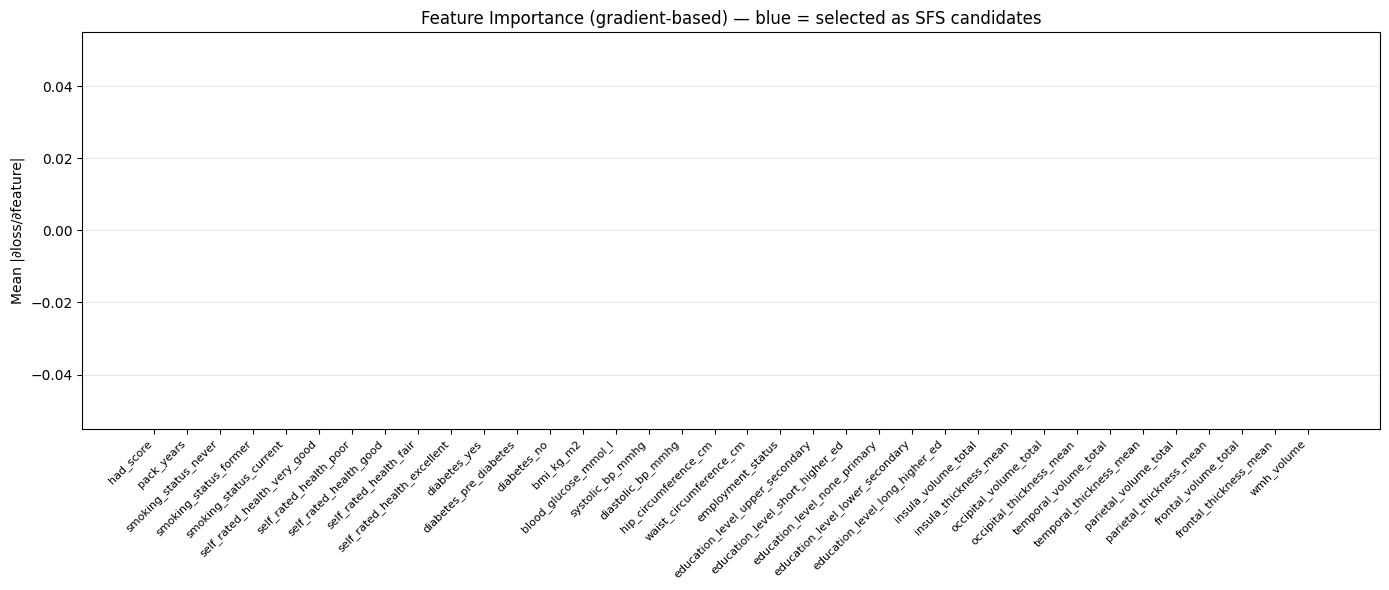

Top-8 candidates: [35, 34, 33, 32, 31, 30, 29, 28]
Names: ['had_score', 'pack_years', 'smoking_status_never', 'smoking_status_former', 'smoking_status_current', 'self_rated_health_very_good', 'self_rated_health_poor', 'self_rated_health_good']


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2196F3' if i < TOP_K else '#BDBDBD' for i in range(N_FEATURES)]
bars = ax.bar(range(N_FEATURES), ranked_scores, color=colors, edgecolor='white')
ax.set_xticks(range(N_FEATURES))
ax.set_xticklabels(ranked_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean |∂loss/∂feature|')
ax.set_title('Feature Importance (gradient-based) — blue = selected as SFS candidates', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

candidate_indices = [int(i) for i in ranked_indices[:TOP_K]]
print(f'Top-{TOP_K} candidates: {candidate_indices}')
print(f'Names: {[FEATURE_NAMES[i] for i in candidate_indices]}')

## 5. Phase 2 — Sequential Forward Selection

⚠️ **Long-running cell** — each training call takes ~2h. The state is saved to  after every completed candidate so you can interrupt and resume freely.

In [7]:
import os
os.makedirs(SFS_OUT_DIR, exist_ok=True)

def train_fn(feature_indices: list[int], run_label: str) -> float:
    val_loss, ckpt = train_with_features(
        feature_indices=feature_indices,
        champion_entry=film_entry,
        base_loader=cond_loader,
        device=device,
        training_pairs=training_pairs,
        validation_pairs=validation_pairs,
        epochs=EPOCHS,
        out_dir=SFS_OUT_DIR,
        run_label=run_label,
        crop_axes=CROP_AXES,
        hide_progress=True,  # SFS will print its own progress
    )
    print(f'  → saved checkpoint: {ckpt}')
    return val_loss

selected_features = run_sfs(
    candidate_indices=candidate_indices,
    train_fn=train_fn,
    results_path=SFS_JSON,
    max_features=MAX_FEATURES,
    min_improvement=1e-4,
)

print(f'[SFS] Final selected features ({len(selected_features)}): {selected_features}')
print(f'Names: {[FEATURE_NAMES[i] for i in selected_features]}')

[SFS] Resuming — already selected 0 feature(s): []

[SFS] Step 1: trying 8 candidate(s)  (prev_loss=inf)


SFS step 1:   0%|          | 0/8 [00:00<?, ?candidate/s, feat=35]

  Training with features [35]  (label=sfs_step1_feat35)


TypeError: train_with_features() got an unexpected keyword argument 'hide_progress'

## 6. SFS Results

In [ ]:
with open(SFS_JSON) as f:
    sfs_state = json.load(f)

steps = sorted(sfs_state['steps'], key=lambda s: s['step'])
step_nums  = [0] + [s['step']         for s in steps]
val_losses = [float('inf')] + [s['val_loss']  for s in steps]
feat_names = [''] + [FEATURE_NAMES[s['best_feature']] for s in steps]

# Replace inf with the first real value for plotting
if val_losses[0] == float('inf') and len(val_losses) > 1:
    val_losses[0] = val_losses[1] * 1.05

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(step_nums[1:], val_losses[1:], 'o-', color='#2196F3', linewidth=2, markersize=8)
for i, (sn, vl, fn) in enumerate(zip(step_nums[1:], val_losses[1:], feat_names[1:])):
    ax.annotate(fn, (sn, vl), textcoords='offset points', xytext=(4, 6), fontsize=8, rotation=15)
ax.set_xlabel('SFS Step (# features selected)')
ax.set_ylabel('Best Val Loss')
ax.set_title('SFS Val Loss vs. Feature Count')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('
Step-by-step summary:')
print(f'  {"Step":>4}  {"Feature added":<35}  {"Val Loss":>10}  {"Improvement":>12}')
print('-' * 70)
for s in steps:
    print(f'  {s["step"]:>4}  {FEATURE_NAMES[s["best_feature"]]:<35}  {s["val_loss"]:>10.6f}  {s["improvement"]:>12.6f}')

## 7. Final Model — Best Feature Subset

Train one last model on the complete selected set and compare against the all-36-features champion.

In [ ]:
# Re-load final selected from JSON in case the SFS cell wasn't just run
with open(SFS_JSON) as f:
    selected_features = sfs_state['selected']

print(f'Training final model on {len(selected_features)} features: {[FEATURE_NAMES[i] for i in selected_features]}')
final_val_loss, final_ckpt = train_with_features(
    feature_indices=selected_features,
    champion_entry=film_entry,
    base_loader=cond_loader,
    device=device,
    training_pairs=training_pairs,
    validation_pairs=validation_pairs,
    epochs=EPOCHS,
    out_dir=SFS_OUT_DIR,
    run_label='final_selected',
    crop_axes=CROP_AXES,
)
print(f'Final model val_loss={final_val_loss:.6f}  checkpoint={final_ckpt}')
print(f'Champion (36 features) val_loss={film_entry["results"]["best_val_loss"]:.6f}')
print(f'Δ = {film_entry["results"]["best_val_loss"] - final_val_loss:+.6f}')